In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as nr
import numpy.fft as nf

In [6]:
Nsub=1024;
Ncp=int(Nsub/4);
itr=1000;
L=9;
#EbdB=np.arange(0,50.1,2.5);
#Eb=10**(EbdB/10);
No=1;
#SNR=2*Eb/No;
#SNRdB=10*np.log10(Eb/No);
SNRdB=np.arange(0,50.1,2.5);
SNR=10**(SNRdB/10);
Eb=SNR*No/2;
EbdB=10*np.log10(Eb/No);

BER=np.zeros(len(EbdB));
SER=np.zeros(len(EbdB));
BERt=np.zeros(len(EbdB));




In [7]:
for i in range(itr):
  noise=nr.normal(0.0,np.sqrt(No/2),L+Nsub+Ncp-1)+1j*nr.normal(0.0,np.sqrt(No/2),L+Nsub+Ncp-1);
  BitsI=nr.randint(2,size=Nsub);
  BitsQ=nr.randint(2,size=Nsub);
  Sym=(2*BitsI-1)+1j*(2*BitsQ-1);
  h=(nr.normal(0.0,1.0,L)+1j*nr.normal(0.0,1,L))/np.sqrt(2);
  hFFT=nf.fft(np.concatenate((h,np.zeros(Nsub-L))));
  for k in range(SNRdB.size):
    LoadedSym=np.sqrt(Eb[k])*Sym;
    TxSamples=nf.ifft(LoadedSym);
    TxSamCP=np.concatenate((TxSamples[Nsub-Ncp:Nsub], TxSamples));
    RxSamCP=np.convolve(h,TxSamCP)+noise;
    RxSamples=RxSamCP[Ncp:Ncp+Nsub];
    RxSym=nf.fft(RxSamples);
    ZFout=RxSym/hFFT;
    DecBitsI=(np.real(ZFout)>0);
    DecBitsQ=(np.imag(ZFout)>0);
    BER[k]=BER[k]+np.sum(DecBitsI != BitsI)+np.sum(DecBitsQ != BitsQ);
    SER[k]=SER[k]+np.sum((DecBitsI != BitsI) | (DecBitsQ != BitsQ));
BER=BER/itr/Nsub/2;
SER=SER/itr/Nsub;
SNReff=SNR*L/Nsub;
BERt=1/2/SNReff;

Text(0, 0.5, 'BER')

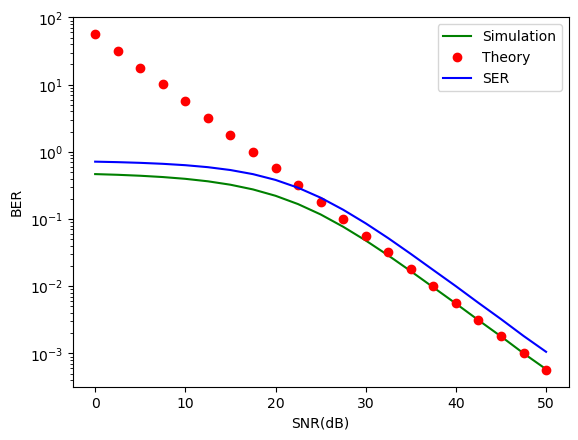

In [8]:
plt.yscale('log')
plt.plot(SNRdB,BER,'g-');
plt.plot(SNRdB,BERt,'ro');
plt.plot(SNRdB,SER,'b-');
plt.legend(["Simulation","Theory","SER"]);
plt.xlabel('SNR(dB)')
plt.ylabel('BER')

In [ ]:
print(SNRdB)

[ 0.   2.5  5.   7.5 10.  12.5 15.  17.5 20.  22.5 25.  27.5 30.  32.5
 35.  37.5 40.  42.5 45.  47.5 50. ]
